# Sales Performance Analytics
## inturn-edu Data Analytics Internship
### By: Kachiya Hiren

## Problem Statement

Analyze Superstore sales data to identify sales trends, top-performing products, regional performance, customer insights, and business opportunities using Python and Power BI.

## Objectives

• Clean the dataset

• Perform Exploratory Data Analysis (EDA)

• Identify Sales Trends

• Find Best and Worst Products

• Analyze Region-wise Performance

• Build Interactive Power BI Dashboard

• Generate Business Insights

pip install pandas numpy matplotlib seaborn jupyter openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
df = pd.read_csv("superstore.csv")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
df.shape

(9800, 18)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [10]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [11]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

In [19]:
df.to_csv("cleaned_superstore.csv", index=False)

## Total Sales

In [20]:
total_sales = df["Sales"].sum()

print("Total Sales:", round(total_sales, 2))

Total Sales: 2252607.41


## Total Orders

In [21]:
total_orders = df["Order ID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 4916


## Average Order Value

In [22]:
average_order_value = total_sales / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 458.22


## Monthly Sales Trend

In [23]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

monthly_sales.head()

,Order Date,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


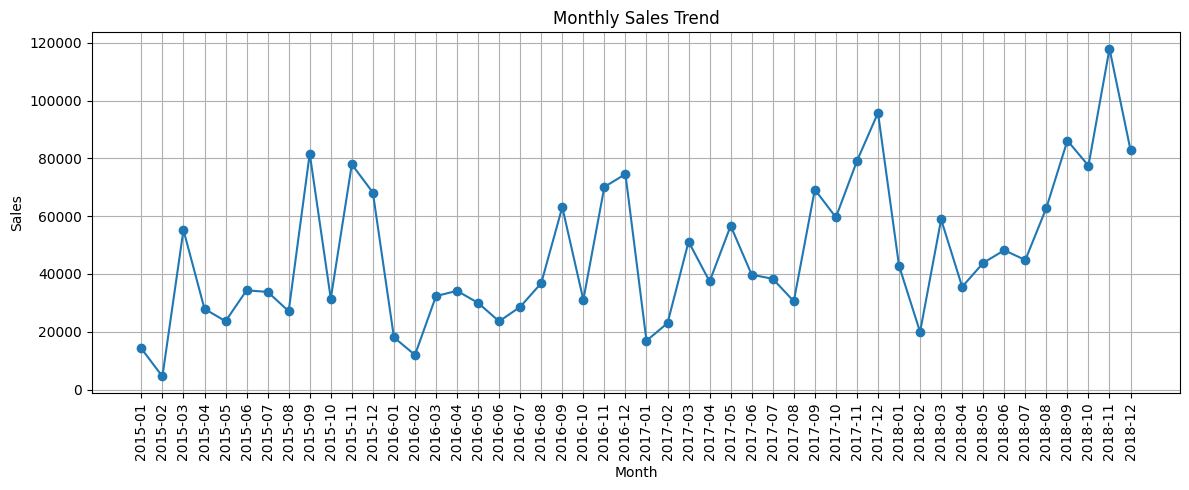

In [39]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.grid(True)

plt.tight_layout()
plt.savefig("monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## Top 5 Products by Sales

In [25]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

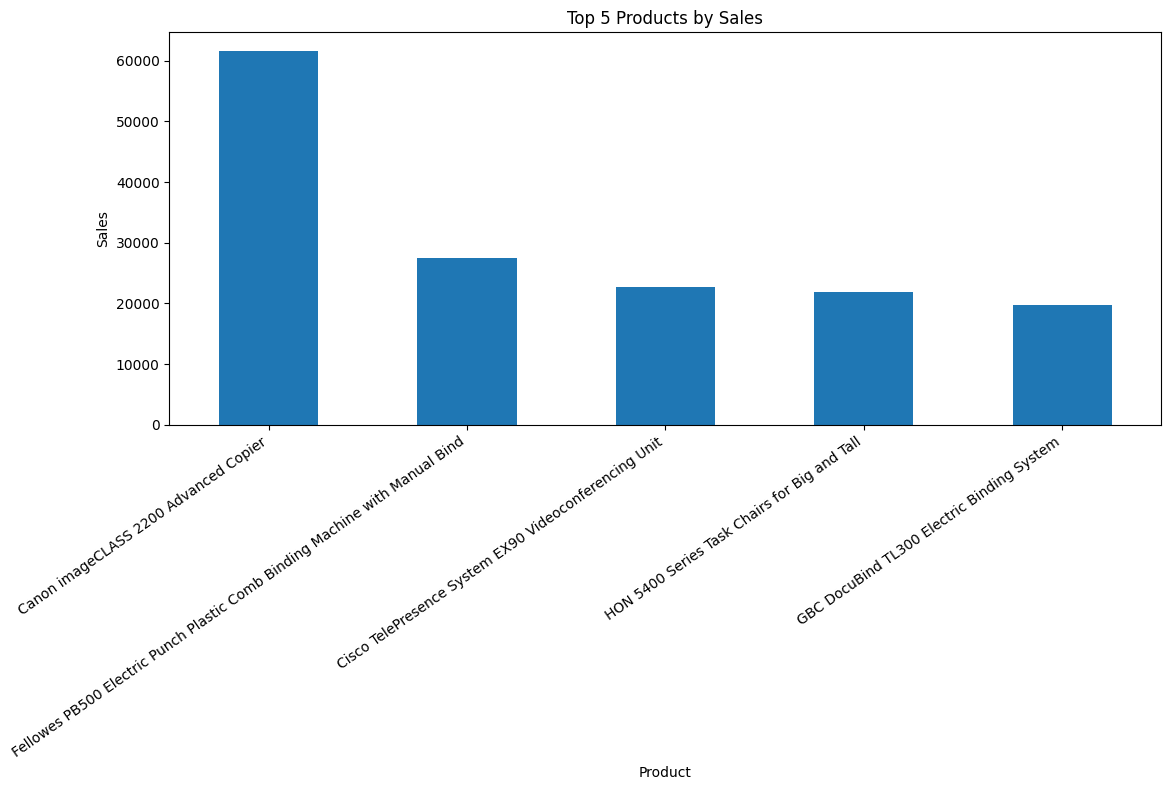

In [45]:
plt.figure(figsize=(12,8))

top_products.plot(kind="bar")

plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.savefig("top5_products.png", dpi=300, bbox_inches="tight")
plt.show()

## Lowest 5 Products by Sales

In [27]:
low_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values()
    .head(5)
)

low_products

Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Name: Sales, dtype: float64

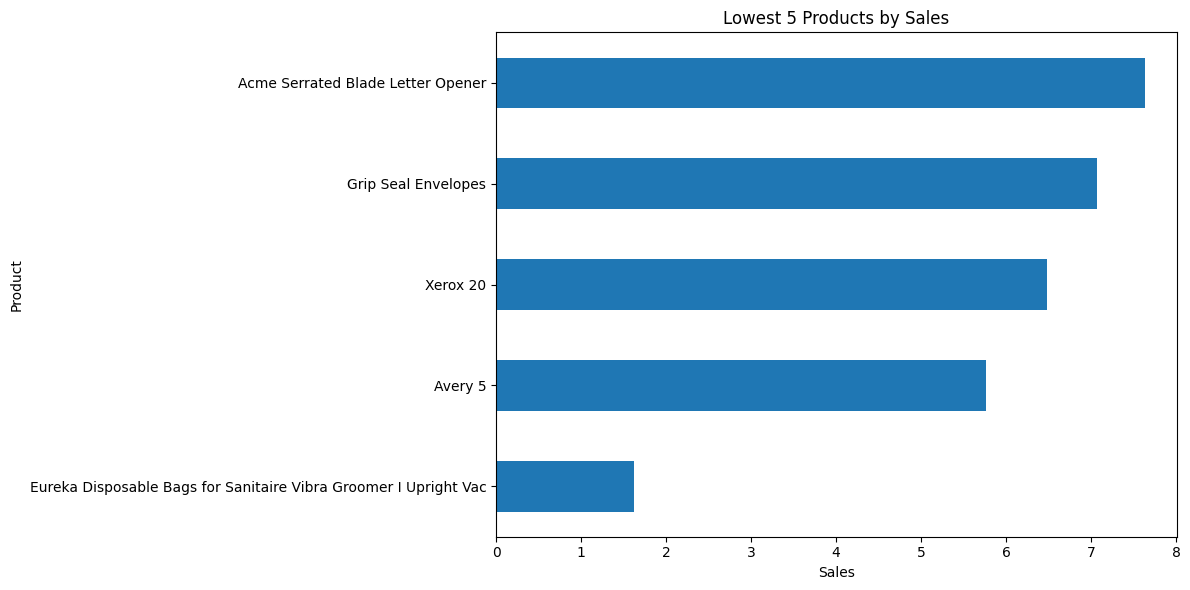

In [46]:
plt.figure(figsize=(12,6))

low_products.sort_values().plot(kind="barh")

plt.title("Lowest 5 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig("lowest5_products.png", dpi=300, bbox_inches="tight")
plt.show()

## Sales by Category

In [29]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
)

category_sales

Category
Furniture          723538.4757
Office Supplies    703212.8240
Technology         825856.1130
Name: Sales, dtype: float64

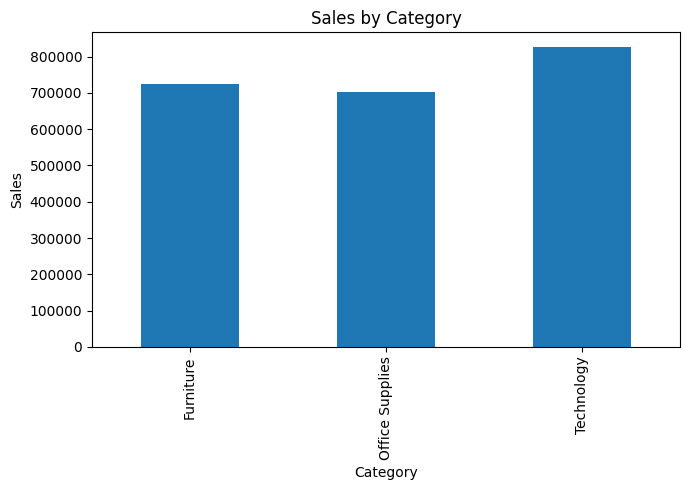

In [42]:
plt.figure(figsize=(7,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

## Sales by Region

In [31]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
)

region_sales

Region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

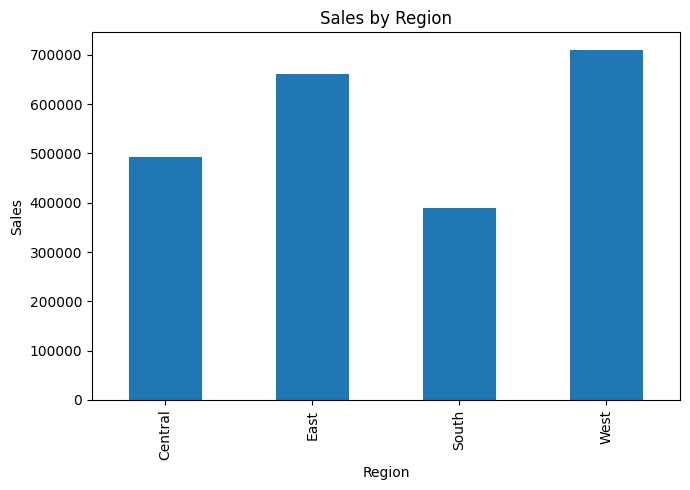

In [43]:
plt.figure(figsize=(7,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

## Top 10 Customers by Sales

In [33]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

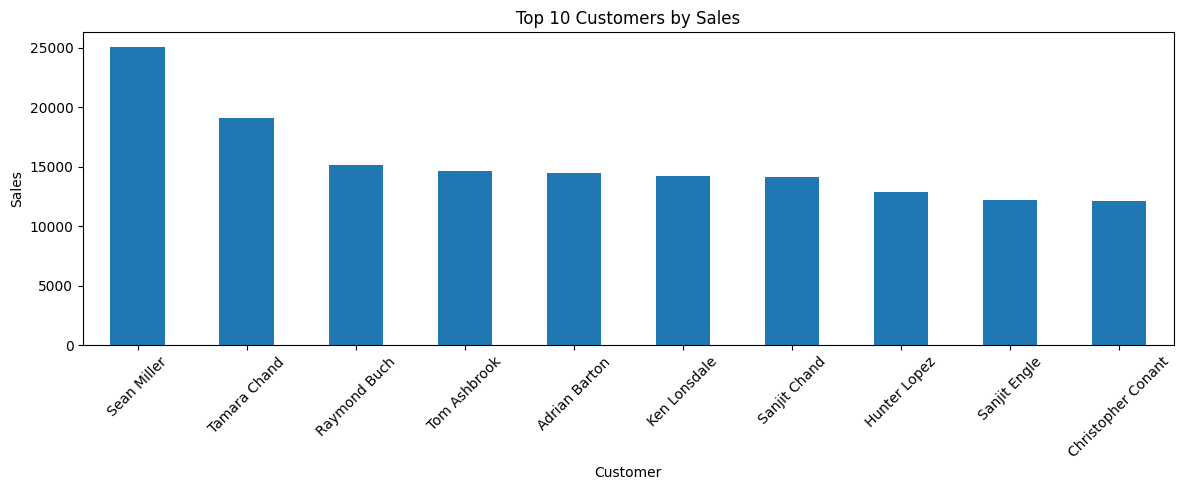

In [44]:
plt.figure(figsize=(12,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("top10_customers.png", dpi=300, bbox_inches="tight")
plt.show()

# Business Insights

1. Total Sales = ₹2,252,607.41

2. Total Orders = 4916

3. Average Order Value = ₹458.22

4. Technology generated the highest sales.

5. West region generated the highest revenue.

6. Canon imageCLASS 2200 Advanced Copier is the best-selling product.

7. Eureka Disposable Bags is the lowest-selling product.

8. Sales peak during September to December.

9. Business should focus more on Technology products and West region.

10. Improve marketing for low-performing products.

# Conclusion

The analysis shows that Technology products contribute the highest sales while West is the strongest region. Sales increase significantly during the last quarter of the year. Business should focus on high-performing categories and improve the sales of low-performing products.